# Session 2: Loading and Visualizing Earth Observation Images
**MOOC Series: From Satellite Data to Insights with Digital Earth Sweden**

---

## Session outline

- Understanding collections: what data is available on Digital Earth Sweden
- Creating a datacube from a collection: temporal and spatial filtering
- Visualizing a Sentinel-2 image: single band, true-color, and false-color

By the end of this session you will have loaded a Sentinel-2 scene over a Swedish city and displayed it on screen in three different ways.

---

## 1. Reconnecting to the backend

We begin every session by reconnecting to the Digital Earth Sweden openEO backend. If you completed Session 1, this pattern should already look familiar.

In [1]:
import openeo

# Connect and authenticate
connection = openeo.connect('https://openeo.digitalearth.se')
connection.authenticate_basic(username='testuser', password='secretpassword')
print('Connected successfully.')

Connected successfully.


## 2. Loading libraries

In addition to OpenEO, we will use 

In [2]:
import io
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

## 3. From collections to datacubes

A **collection** on Digital Earth Sweden is a large, organised repository of satellite imagery covering Sweden over time.

In [3]:
# Inspect the DES Sentinel-2 Level 2 collection
info = connection.describe_collection('des_s2_msi_l2a')
print('Collection title:', info.get('title'))
print('Temporal extent :', info.get('extent', {}).get('temporal'))

# List available bands
summaries = info.get('summaries', {})
bands = summaries.get('eo:bands', [])
print('\nAvailable bands:')
for b in bands:
    print(f"  {b.get('name', '?'):6s}  {b.get('description', '')}")

Collection title: des_s2_msi_l2a
Temporal extent : {'interval': [['2026-05-31T10:36:19.024000Z', '2026-07-12T10:26:01.025000Z']]}

Available bands:


When you work with a collection you never download the whole archive. Instead you specify:

- A **spatial extent** — the geographic bounding box of your area of interest.
- A **temporal extent** — the start and end dates.
- A list of **spectral bands** — which channels to include.

The result is a **datacube**: a structured, multi-dimensional array of pixel values ready for analysis.

[![Datacube Timeseries](https://openeo.org/assets/img/dc_timeseries.c2c7a902.png)](https://openeo.org/assets/img/dc_timeseries.c2c7a902.png)

In this course we use `des_s2_msi_l2a` — analysis-ready Sentinel-2 Level 2 surface reflectance. Level 2 means the data has been corrected for atmospheric effects, so pixel values represent actual reflectance at the Earth's surface rather than at the top of the atmosphere.

## 4. Defining and loading a datacube

We will work over **Karlstad**, a city in central Sweden on the northern shore of Lake Vänern. The bounding box below covers the urban core and some surrounding forest and lake areas — a varied landscape useful for visualisation.

Coordinates are given in **WGS84 (EPSG:4326)**: longitude (east–west) and latitude (north–south).

In [4]:
# Area of interest: Karlstad city centre and surroundings
aoi = {
    'west':  13.460930954751282,
    'east':  13.585449709728213,
    'south': 59.36327761288911,
    'north': 59.40107161575003,
    'crs':   'EPSG:4326',
}

# We will load a cloud-free autumn scene
timespan = ['2026-06-01', '2026-07-01']

# Cloud cover threshold (optional)
max_cloud_cover = 20

print('Area of interest:', aoi)
print('Time range      :', timespan)

Area of interest: {'west': 13.460930954751282, 'east': 13.585449709728213, 'south': 59.36327761288911, 'north': 59.40107161575003, 'crs': 'EPSG:4326'}
Time range      : ['2026-06-01', '2026-07-01']


The `load_collection` call below does **not** download any data yet. It builds a **process graph** — a recipe that describes what data to retrieve and how. The data will be fetched from the DES backend only when we call `.download()`.

We load four bands: **B02** (Blue), **B03** (Green), **B04** (Red), and **B08** (Near-infrared).

The table below lists the most commonly used Sentinel-2 spectral bands:
| Band | Name | Wavelength (nm) | Resolution | Typical use |
|---|---|---|---|---|
| B02 | Blue | 490 | 10 m | True-colour composites |
| B03 | Green | 560 | 10 m | True-colour composites |
| B04 | Red | 665 | 10 m | Vegetation indices |
| B08 | NIR | 842 | 10 m | Vegetation indices |

In [5]:
datacube = connection.load_collection(
    collection_id='des_s2_msi_l2a',
    spatial_extent=aoi,
    temporal_extent=timespan,
    bands=['B02', 'B03', 'B04', 'B08'],
    properties = {'eo:cloud_cover': lambda x: x <= max_cloud_cover},
)

print('Datacube defined. Use .download() to retrieve the data.')

Datacube defined. Use .download() to retrieve the data.


## 5. Downloading the data

For visualization purpose, we only download a single scene. We do this by selecting the first scene in the datacube.

Finally, we can run the processing graph on DES by downloading the selected scene using the GeoTIFF format.

Once downloaded, the data can be extracted and loaded into Python using the `xarray` library. This is particularly useful for visualization and further spatial analysis.

In [6]:
# Pick the first available scene using the reduction method (we will look at dimension reduction in detail in Session 4) 
image = datacube.reduce_dimension(dimension='t', reducer='first')

# Downloading the image as GeoTIFF
image_tif = image.download(format='GTiff')

# Load into xarray
da = xr.open_dataarray(io.BytesIO(image_tif), engine='rasterio')
da = da.assign_coords(band=['B02', 'B03', 'B04', 'B08'])

## 6. Accessing the image data

The image, including its reflectance values and metadata, is now stored in local memory as an `xarray.DataArray` object.

We can explore the data by printing the object.

We can also access the reflectance values directly using the `.values` attribute, which converts the array data into a `numpy` array.

It is worth noting that reflectance values are stored as integers in the range 0–10,000 for storage efficiency. To obtain reflectance values in the standard [0, 1] range, we simply rescale the data by dividing by 10,000.

In [7]:
print(da)
# print(da.values)

# Rescaling reflectance values to [0, 1]
da = (da.astype(np.float32) / 10_000).clip(0, 1)

<xarray.DataArray 'band_data' (band: 4, y: 438, x: 718)> Size: 5MB
[1257936 values with dtype=float32]
Coordinates:
  * x            (x) float64 6kB 4.125e+05 4.125e+05 ... 4.197e+05 4.197e+05
  * y            (y) float64 4kB 6.586e+06 6.586e+06 ... 6.581e+06 6.581e+06
    spatial_ref  int64 8B ...
  * band         (band) <U3 48B 'B02' 'B03' 'B04' 'B08'
Attributes:
    AREA_OR_POINT:                  Area
    band_names:                     B02,B03,B04,B08
    collection:                     des_s2_msi_l2a
    reduced_dimensions_min_values:  {"t": "2026-06-11T10:17:01.024000000"}
    timestamp:                      2026-07-13T14:05:13.849126000
    long_name:                      ('B02', 'B03', 'B04', 'B08')


## 7. Visualizing the image

We will now visualize the image we downloaded using the `.plot` accessor of the `xarray.DataArray` object.

We start simple by visualizing the **Red band (B04)** in greyscale. This is the channel closest to what the human eye perceives as red light (665 nm). To improve contrast, we set `vmax` in the `.imshow` method to 0.4, meaning reflectance values above 0.4 will be displayed as white. 

Bright areas in this image represent high reflectance in the red spectrum — typically bare soil, rooftops, or roads. Dark areas absorb red light — typically water and healthy vegetation.

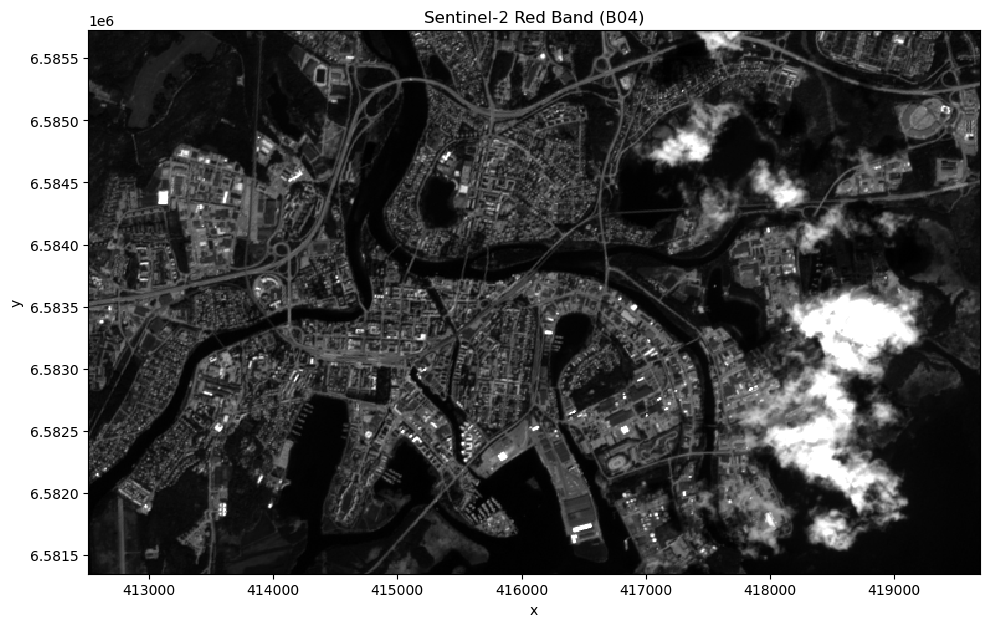

In [8]:
# Select red band
red = da.sel(band='B04')

# Vizualize 
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
red.plot.imshow(ax=ax, cmap='gray', vmin=0, vmax=0.4, add_colorbar=False)
ax.set_aspect('equal')
ax.set_title('Sentinel-2 Red Band (B04)')
plt.tight_layout()
plt.show()

We can also create color visualizations using the `.plot` accessor by selecting a triple of spectral bands and setting `rgb='band'` in`.imshow`.

We start with a true color visualization by selecting the Sentinel-2 red (B04), green (B03) and blue (B02) bands for true color visualization:
- **R** → Red band (B04)
- **G** → Green band (B03)
- **B** → Blue band (B02)

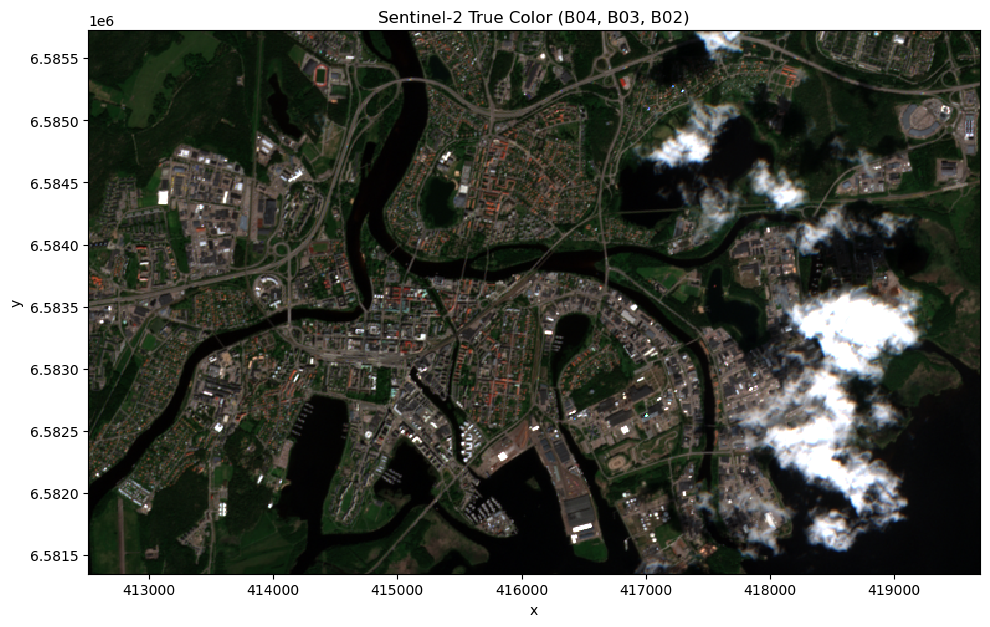

In [9]:
# Create true color visualization
rgb = da.sel(band=['B04', 'B03', 'B02'])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
rgb.plot.imshow(rgb='band', vmin=0, vmax=0.4, ax=ax)
ax.set_aspect('equal')
ax.set_title('Sentinel-2 True Color (B04, B03, B02)')
plt.tight_layout()
plt.show()

The same approach can be used to create false color  visualization, such as the false color visualization introduced in Session 1:

- **R** → Near-infrared (B08)
- **G** → Red (B04)
- **B** → Green (B03)

In this band combination, **healthy vegetation appears bright red** because it reflects strongly in the NIR channel. Urban surfaces, water, and bare soil appear in shades of blue, grey, and cyan.

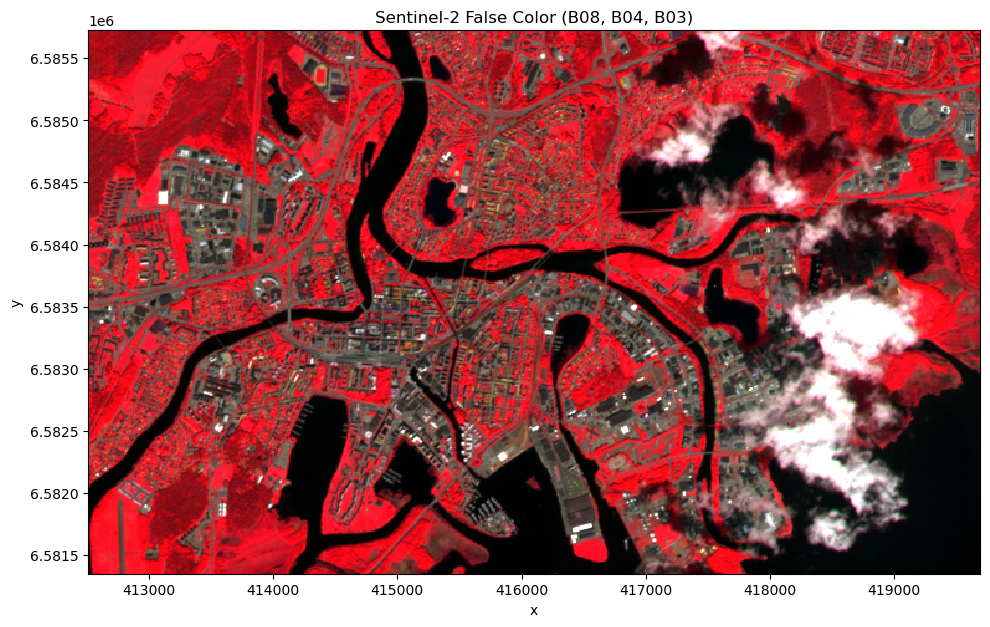

In [10]:
# Create false color visualization
rgb = da.sel(band=['B08', 'B04', 'B03'])

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
rgb.plot.imshow(rgb='band', vmin=0, vmax=0.4, ax=ax)
ax.set_aspect('equal')
ax.set_title('Sentinel-2 False Color (B08, B04, B03)')
plt.tight_layout()
plt.show()

**What do you notice?** Compare the true-color and false-color composites side by side. The bright red areas in the false-color image correspond to forested areas and urban parks — precisely the vegetation we will map in Session 6.

---

## Summary

In this session you:

- Learned how collections and datacubes are structured in openEO.
- Defined a spatial and temporal extent to load a Sentinel-2 scene over Karlstad.
- Visualized the Red band as a single-channel greyscale image.
- Created a true-color RGB composite that mimics natural colors.
- Created a false-color NIR composite where healthy vegetation appears red.

**Next session:** we go beyond visualization and perform our first quantitative analysis — computing the Normalized Difference Vegetation Index (NDVI) using band arithmetic.

---
*Digital Earth Sweden MOOC — Session 2 of 6*